In [12]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np

mnist = fetch_openml('mnist_784', version=1, as_frame=False) # X: (70000, 784)
X, y = mnist["data"], mnist["target"]
X = X.astype(np.float32) / 255.0
y = y.astype(np.int64)
# scale to [0, 1]
X_trainval, X_test, y_trainval, y_test = train_test_split(
X, y, test_size=10000, random_state=42, stratify=y
)


In [13]:
import os
from torch import nn

class MLP_Model(nn.Module):
    def __init__(self):
        super(MLP_Model, self).__init__()
        self.input = nn.Linear(784,2 * 784 )
        self.hidden = nn.Linear(2*784, 2*784)
        self.output = nn.Linear(2*784, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.input(x))
        x = self.relu(self.hidden(x))
        x = self.output(x)

        return x


os.makedirs('Models/SGD', exist_ok=True)

# SGD Model without optim

---FOLD 0 ---


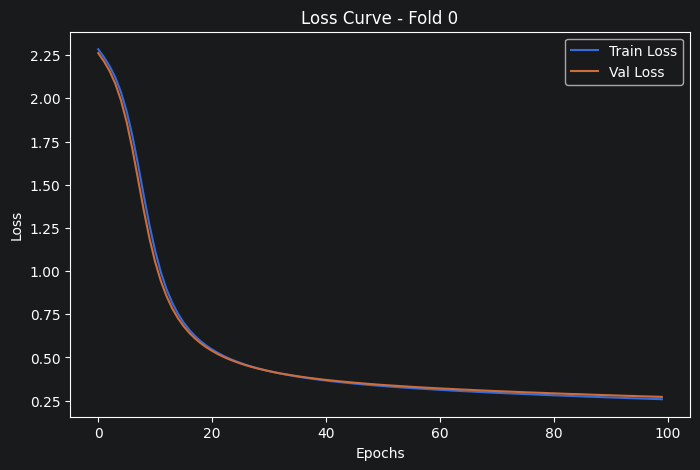

---FOLD 1 ---


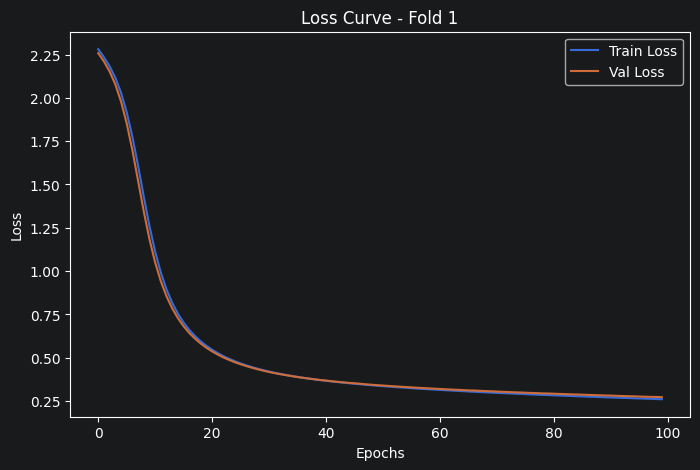

---FOLD 2 ---


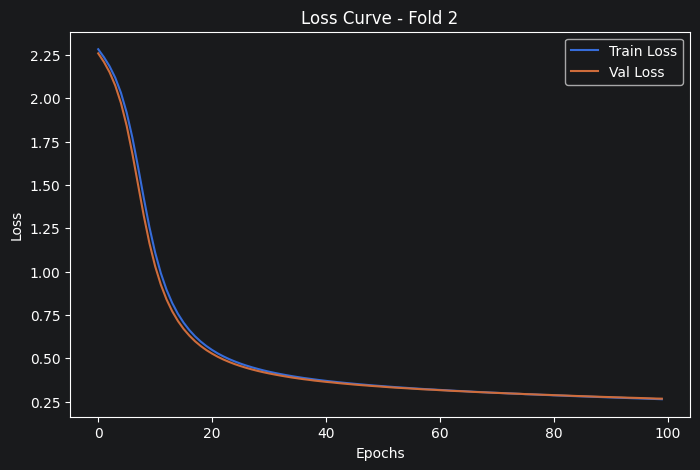

---FOLD 3 ---


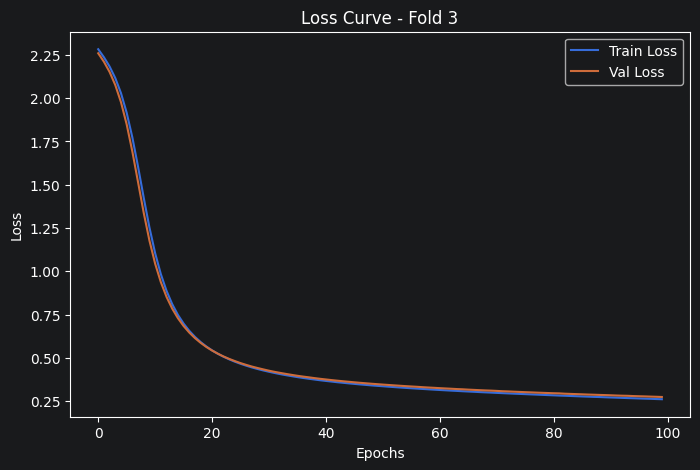

---FOLD 4 ---


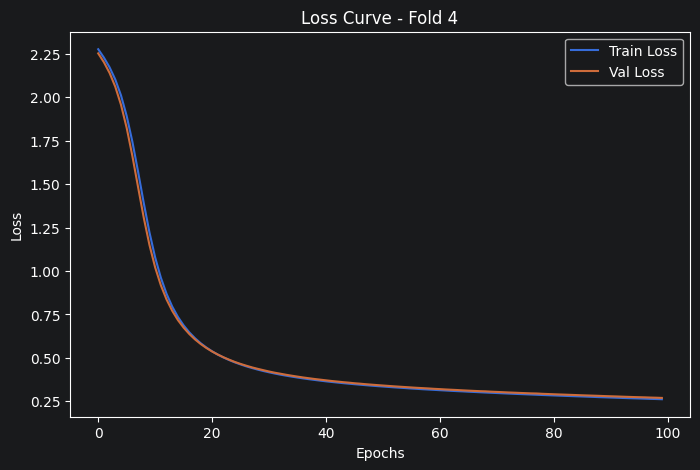

In [14]:
from matplotlib import pyplot as plt
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset
from sklearn.model_selection import KFold

# --- Data ---
X_trainval_tensor = torch.from_numpy(X_trainval).float()
y_trainval_tensor = torch.from_numpy(y_trainval).long()
dataset = TensorDataset(X_trainval_tensor, y_trainval_tensor)

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_SPLITS = 5
N_EPOCHS = 100
BATCH    = 1024

# Hyperparameters
lr = 0.01

folds = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_index, val_index) in enumerate(folds.split(X_trainval)):
    print(f"---FOLD {fold} ---")

    # Fold Split and Loaders
    train_sample = Subset(dataset, train_index)
    val_sample = Subset(dataset, val_index)

    train_loader = DataLoader(train_sample, batch_size=BATCH, shuffle=True)
    val_loader = DataLoader(val_sample, batch_size=BATCH, shuffle=False)

    #Model, Optimizer and Loss
    model = MLP_Model().to(DEVICE)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    history = {'train_loss':[], 'val_loss':[]}

    # Training Loop
    model.train()

    for epoch in range(N_EPOCHS):
        train_running_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            train_running_loss += loss.item()

        avg_train_loss = train_running_loss / len(train_loader)

        # Model Validation
        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for x,y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                output = model(x)
                loss = criterion(output, y)
                val_running_loss += loss.item()

        avg_val_loss = val_running_loss / len(val_loader)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)

        # Saving Best Model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            checkpoint = {
                'epoch': epoch,
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'best_val_loss': best_val_loss,
                'history': history
            }
            PATH = os.path.join('Models', 'SGD', f'model_{fold}.pth')
            torch.save(checkpoint, PATH)
            #print(f"Epoch {epoch}: Model Saved with new best loss {avg_val_loss:.4f}")


    # Vizualization
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f'Loss Curve - Fold {fold}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

## Optuna Objective

In [17]:
import optuna
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset
from sklearn.model_selection import KFold

# --- Data ---
X_trainval_tensor = torch.from_numpy(X_trainval).float()
y_trainval_tensor = torch.from_numpy(y_trainval).long()
dataset = TensorDataset(X_trainval_tensor, y_trainval_tensor)

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_SPLITS = 5
N_EPOCHS = 5
BATCH    = 1024


def _train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        criterion(model(X), y).backward()
        optimizer.step()

def _calculate_val_loss(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for X,y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            output = model(X)
            loss = criterion(output, y)
            running_loss += loss.item()
    avg_loss = running_loss / len(loader)

    return avg_loss


def objective(trial: optuna.Trial) -> float:
    # Parameters
    lr       = trial.suggest_float("learning_rate", 1e-4, 5e-1, log=True)
    momentum = trial.suggest_float("momentum", 0.0, 0.99)
    nesterov = trial.suggest_categorical("nesterov", [True, False])
    if momentum == 0.0:
        nesterov = False


    criterion = nn.CrossEntropyLoss()
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    fold_loss = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_trainval)):
        train_loader = DataLoader(
            Subset(dataset, train_idx), batch_size=BATCH, shuffle=True
        )
        val_loader = DataLoader(
            Subset(dataset, val_idx), batch_size=BATCH
        )

        model = MLP_Model().to(DEVICE)

        optimizer = optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=momentum,
            nesterov=nesterov,
        )

        for epoch in range(N_EPOCHS):
            _train_one_epoch(model, train_loader, optimizer, criterion)

        fold_loss.append(_calculate_val_loss(model, val_loader, criterion))

    return float(np.mean(fold_loss))




study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=25, timeout=1800, show_progress_bar=True)

print("Best parameters:", study.best_params)
print("Mean avg val loss CV: ", study.best_value)

[I 2026-03-31 07:13:21,168] A new study created in memory with name: no-name-f6a53690-4d63-4b29-a2bf-cf5d9ad72b47


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-03-31 07:13:41,241] Trial 0 finished with value: 0.39314445356527966 and parameters: {'learning_rate': 0.05586981249841082, 'momentum': 0.22427306360494456, 'nesterov': False}. Best is trial 0 with value: 0.39314445356527966.
[I 2026-03-31 07:14:00,576] Trial 1 finished with value: 0.3008262366056442 and parameters: {'learning_rate': 0.11247850623640004, 'momentum': 0.2933768510692702, 'nesterov': True}. Best is trial 1 with value: 0.3008262366056442.
[I 2026-03-31 07:14:17,913] Trial 2 finished with value: 2.1497989177703856 and parameters: {'learning_rate': 0.003444943583896607, 'momentum': 0.42657249266576996, 'nesterov': False}. Best is trial 1 with value: 0.3008262366056442.
[I 2026-03-31 07:14:36,500] Trial 3 finished with value: 0.2952278743187587 and parameters: {'learning_rate': 0.06788579618642097, 'momentum': 0.5827187425805267, 'nesterov': True}. Best is trial 3 with value: 0.2952278743187587.
[I 2026-03-31 07:14:55,235] Trial 4 finished with value: 0.25513901834686

# Models with Optimized Parameters

---FOLD 0 ---


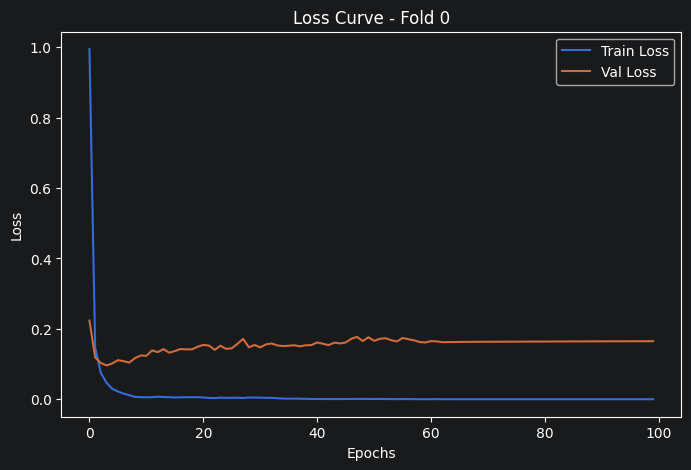

---FOLD 1 ---


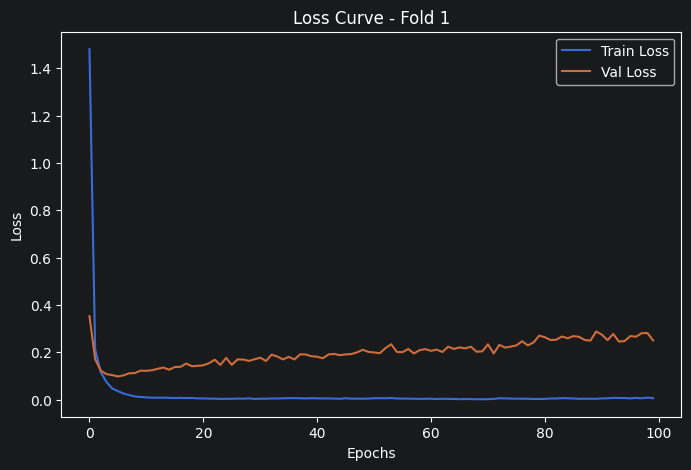

---FOLD 2 ---


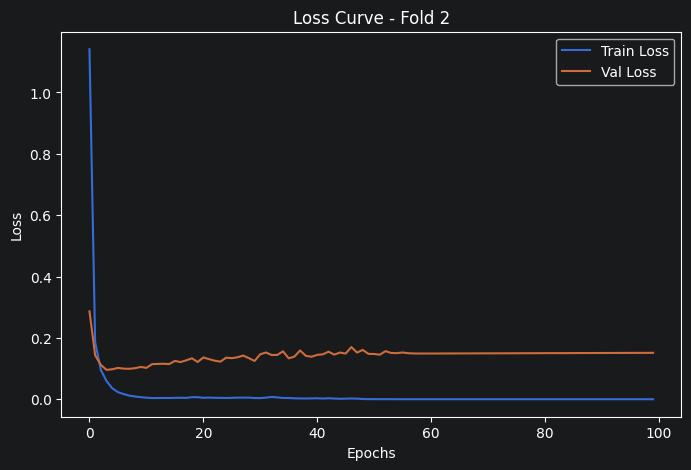

---FOLD 3 ---


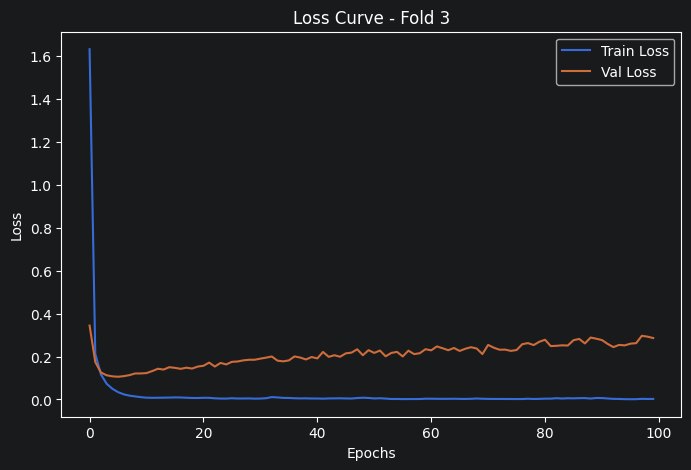

---FOLD 4 ---


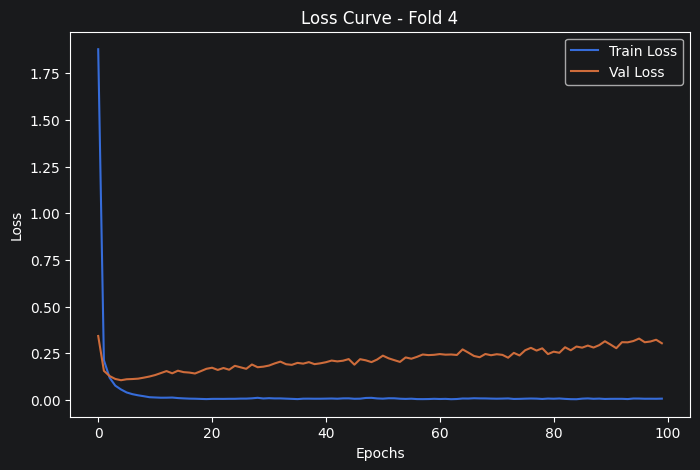

In [20]:
from matplotlib import pyplot as plt

N_EPOCHS = 100

folds = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_index, val_index) in enumerate(folds.split(X_trainval)):
    print(f"---FOLD {fold} ---")

    # Fold Split and Loaders
    train_sample = Subset(dataset, train_index)
    val_sample = Subset(dataset, val_index)

    train_loader = DataLoader(train_sample, batch_size=BATCH, shuffle=True)
    val_loader = DataLoader(val_sample, batch_size=BATCH, shuffle=False)

    #Model, Optimizer and Loss
    model = MLP_Model().to(DEVICE)
    optimizer = optim.SGD(model.parameters(), momentum=study.best_params["momentum"],
                          nesterov=study.best_params["nesterov"], lr=study.best_params["learning_rate"])
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    history = {'train_loss':[], 'val_loss':[]}

    # Training Loop
    for epoch in range(N_EPOCHS):

        model.train()
        train_running_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            train_running_loss += loss.item()

        avg_train_loss = train_running_loss / len(train_loader)

        # Model Validation
        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for x,y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                output = model(x)
                loss = criterion(output, y)
                val_running_loss += loss.item()

        avg_val_loss = val_running_loss / len(val_loader)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)

        # Saving Best Model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            checkpoint = {
                'epoch': epoch,
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'best_val_loss': best_val_loss,
                'history': history
            }
            PATH = os.path.join('Models', 'SGD', f'model2_{fold}.pth')
            torch.save(checkpoint, PATH)
            #print(f"Epoch {epoch}: Model Saved with new best loss {avg_val_loss:.4f}")


    # Vizualization
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f'Loss Curve - Fold {fold}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Val Loss Comprhension
Optimizer is clearly optimized to have the lowest as possible val loss in 5 epochs (as we used 5 epochs in optuna objective).

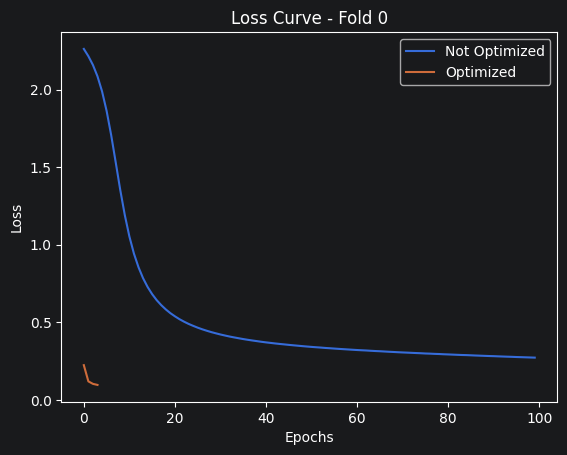

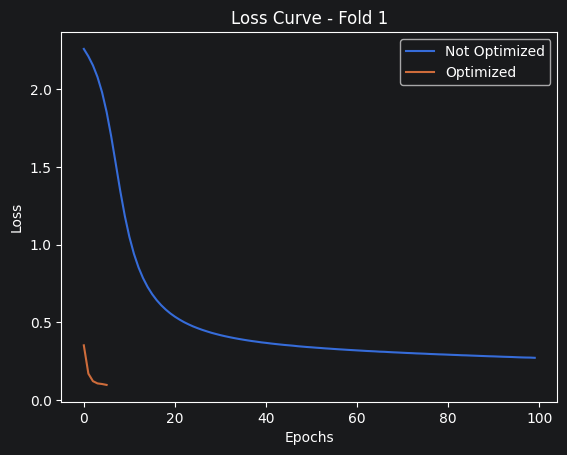

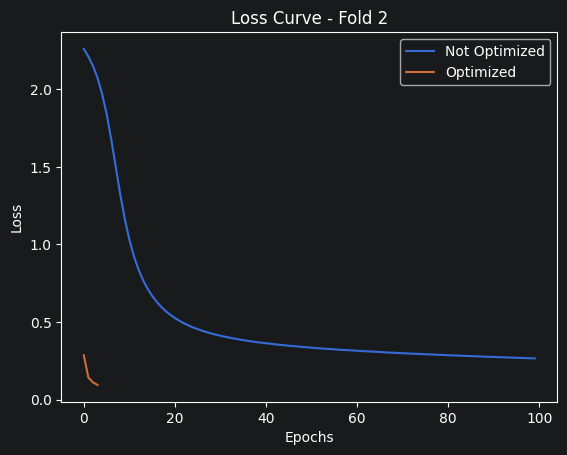

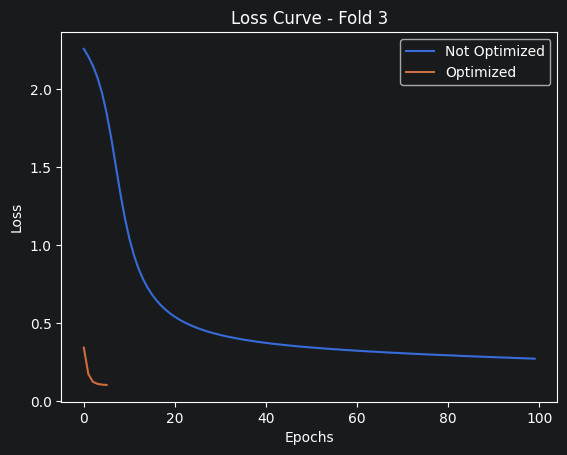

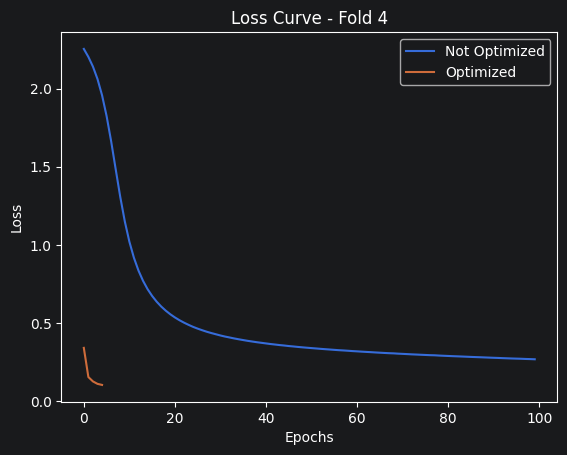

In [21]:
for i in range(5):
    checkpoint1 = torch.load(os.path.join('Models','SGD', f'model_{i}.pth'))
    checkpoint2 = torch.load(os.path.join('Models', 'SGD', f'model2_{i}.pth'))
    val_loss_not_optimized = checkpoint1['history']['val_loss']
    val_loss_optimized = checkpoint2['history']['val_loss']

    plt.plot(val_loss_not_optimized, label='Not Optimized')
    plt.plot(val_loss_optimized, label='Optimized')
    plt.title(f'Loss Curve - Fold {i}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()